In [121]:
from __future__ import print_function, division
import scipy

import keras
import tensorflow as tf
#import tensorflow-addons as tfa
#import tensorflow_addons as tfa
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()
from tensorflow.keras.regularizers import l2
from tensorflow.keras.layers import Input, Dense, Reshape, Flatten, Dropout, Concatenate
from tensorflow.keras.layers import BatchNormalization, Activation, ZeroPadding2D
#from keras.layers.advanced_activations import LeakyReLU
from tensorflow.keras.layers import LeakyReLU,ReLU,Add, PReLU,add
from tensorflow.keras.layers import UpSampling2D, Conv2D, MaxPooling2D, Conv2DTranspose, SeparableConv2D
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.optimizers import schedules
from tensorflow.keras.layers import MaxPool2D,multiply,Lambda
from keras import backend as K
import numpy as np
import matplotlib.pyplot as plt
import glob
import os

### Training values

In [122]:
from tensorflow.keras.applications import EfficientNetB4
from tensorflow.keras.layers import RandomRotation,RandomTranslation,RandomFlip,RandomContrast


In [456]:
#hist=np.load('./resized_vgg_sum_myloss_pret_lr0p00001_class_weight/history.npy',allow_pickle=True).item()
#hist=np.load('./history.npy',allow_pickle=True).item()
#hist=np.load('./history_lr0p00005dyn.npy',allow_pickle=True).item()
#hist=np.load('./history_vgg_lr0p0005dyn.npy',allow_pickle=True).item()
#hist=np.load('./history_vgg_lr0p0001dyn.npy',allow_pickle=True).item()
#hist=np.load('./expes/resnet/lr0p00005dyn/history.npy',allow_pickle=True).item()
#hist=np.load('./expes/resnet/lr0p0001dyn/history.npy',allow_pickle=True).item()
#hist=np.load('./expes/resnet/lr0p0005dyn/history.npy',allow_pickle=True).item()
#hist=np.load('./expes/vgg/lr0p0005dyn/history.npy',allow_pickle=True).item()
#hist=np.load('./expes/resnet/lr0p001wei/history.npy',allow_pickle=True).item()
#hist=np.load('./expes/vgg_train/lr0p001wei/history.npy',allow_pickle=True).item()

#hist=np.load('./expes/unet/lr0p001wei/history.npy',allow_pickle=True).item() 
#hist=np.load('./recup/resnetencours/lr0p0005wei///history.npy',allow_pickle=True).item() 
#hist=np.load('./recup/resnetencours/lr0p0001wei///history.npy',allow_pickle=True).item() 
#hist=np.load('./recup/resnetencours/lr0p005wei///history.npy',allow_pickle=True).item() 
#hist=np.load('./expes/resnet_train/lr0p00005wei/history.npy',allow_pickle=True).item()
#hist=np.load('./expes/vgg_train/lr0p0001wei/history.npy',allow_pickle=True).item()
#hist=np.load('./expes/vgg_train/lr0p0005wei/history.npy',allow_pickle=True).item()



#hist=np.load('./recup/resnetencours/resnet_lr0p001wei_hist.npy',allow_pickle=True).item() 
#hist=np.load('./recup/resnetencours/resnet_lr0p005wei_hist.npy',allow_pickle=True).item() 
#hist=np.load('./recup/vgg/lr0p00005wei//history.npy',allow_pickle=True).item() 
#hist=np.load('./recup/vgg/lr0p00001wei//history.npy',allow_pickle=True).item() 
#hist=np.load('./recup/vgg/lr0p001wei//history.npy',allow_pickle=True).item() 
#hist=np.load('./recup/vgg_back/lr0p0005wei//history.npy',allow_pickle=True).item() 
#hist=np.load('./recup/vgg_back/lr0p00005wei///history.npy',allow_pickle=True).item() 

# Regarder le début
#hist=np.load('./expes/resnet_train/lr0p0001wei/history.npy',allow_pickle=True).item() 
#hist=np.load('./recup/resnet_train/lr0p0005wei/history.npy',allow_pickle=True).item() 
#hist=np.load('./expes/unet/lr0p001wei/history.npy',allow_pickle=True).item() 
hist=np.load('./expes/unet/lr0p00005wei_pret//history.npy',allow_pickle=True).item() 


print('saved keys')
for key in hist.keys():
    print(key)

saved keys
loss
accuracy
f1_m
binary_io_u
val_loss
val_accuracy
val_f1_m
val_binary_io_u


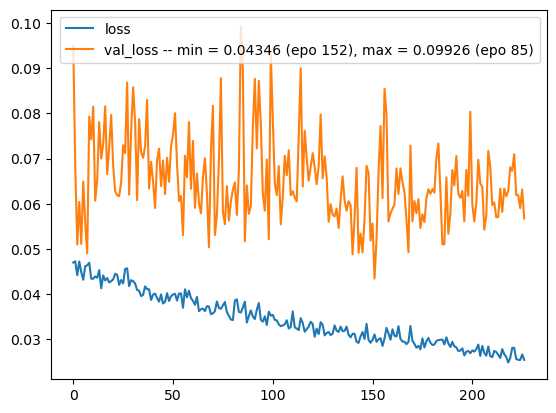

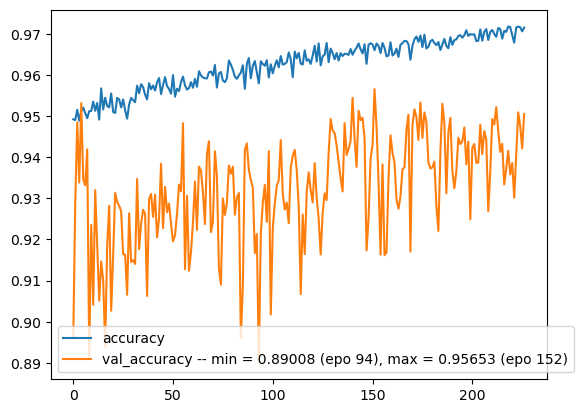

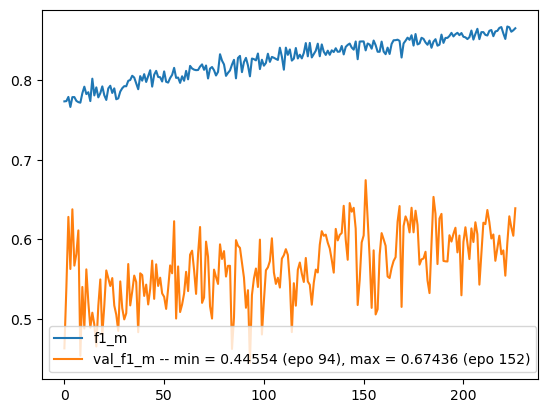

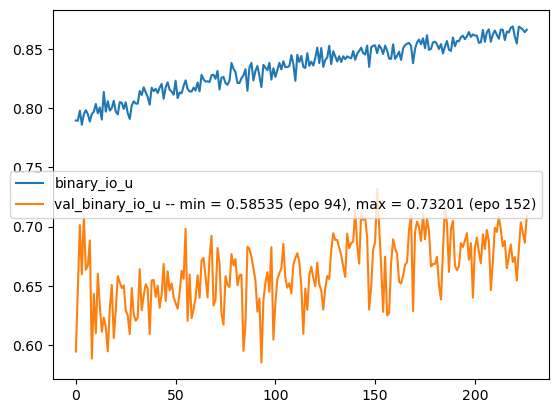

In [457]:
names = list(hist)
pas= len(names)//2
for i in range(0,pas):
    plt.figure()
    plt.plot(hist[names[i]])
    plt.plot(hist[names[i+pas]])
    i_min_ax2=np.argmin(hist[names[i+pas]])
    i_max_ax2=np.argmax(hist[names[i+pas]])
    vmin=hist[names[i+pas]][i_min_ax2]
    vmax=hist[names[i+pas]][i_max_ax2]
    axe2='%s -- min = %.5f (epo %d), max = %.5f (epo %d)'%(names[i+pas],vmin,i_min_ax2+1,vmax,i_max_ax2+1)
    plt.legend([names[i],axe2])
    


In [285]:
#hist=np.load('./constant_vgg_sum_myloss_pret/history.npy',allow_pickle=True).item()
print('saved keys')
for key in hist.keys():
    print(key)


saved keys
loss
accuracy
f1_m
binary_io_u
val_loss
val_accuracy
val_f1_m
val_binary_io_u


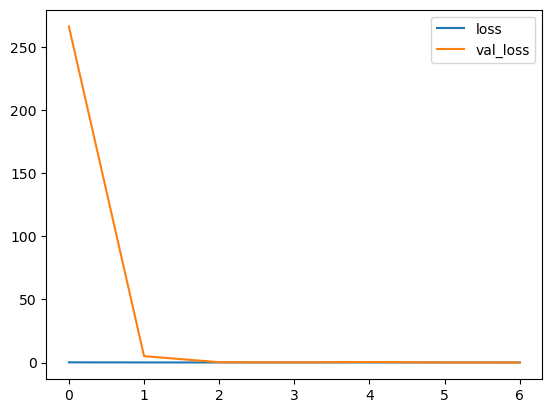

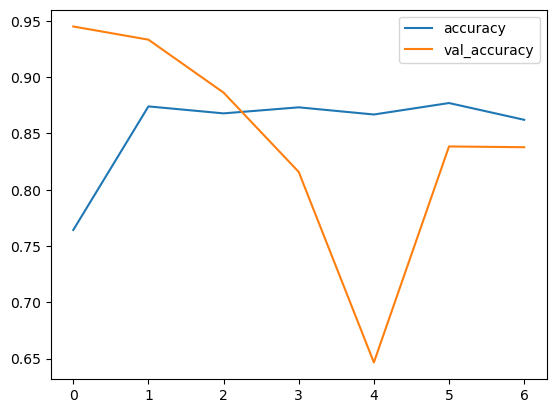

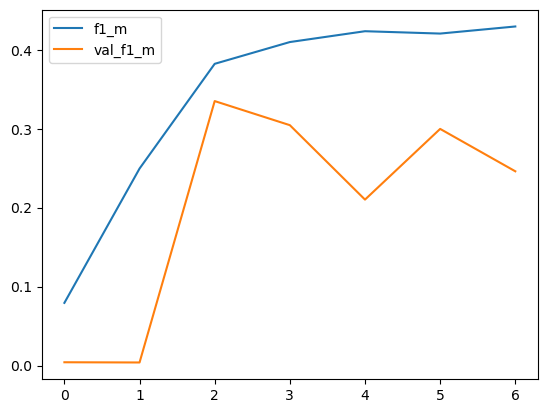

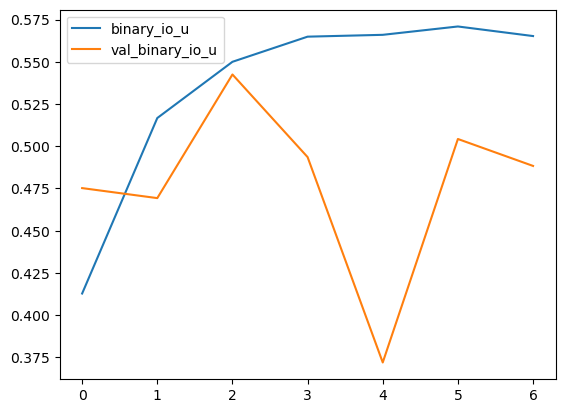

In [334]:
names = list(hist)
pas= len(names)//2
delais=7
for i in range(0,pas):
    plt.figure()
    plt.plot(hist[names[i]][0:delais])
    plt.plot(hist[names[i+pas]][0:delais])
    plt.legend([names[i],names[i+pas]])



### On line plotting

In [168]:
def plot_val_loss(path_model,name_out=None):
    #path_model='./constant_resnet_sum_myloss_lr0p0005/models/'
    #name_out='./curves/'
    liste_in=glob.glob('%s/mod*h5'%path_model)
    liste_in.sort
    it=[]
    loss=[]
    val=[]
    for i in range(len(liste_in)):
        generic_name=os.path.split(liste_in[i])[1]
        p=generic_name.split(sep='-')
        it.append(int(p[1]))
        loss.append(float(p[2]))
        valtmp=os.path.splitext(p[3])
        val.append(float(valtmp[0]))

    indices=np.argsort(it)
    fig=plt.plot(np.array(it)[indices],np.array(loss)[indices])
    fig=plt.plot(np.array(it)[indices],np.array(val)[indices])
    fig=plt.legend(['loss','val'])
    if name_out != None:
        fig.figure.savefig(name_out)


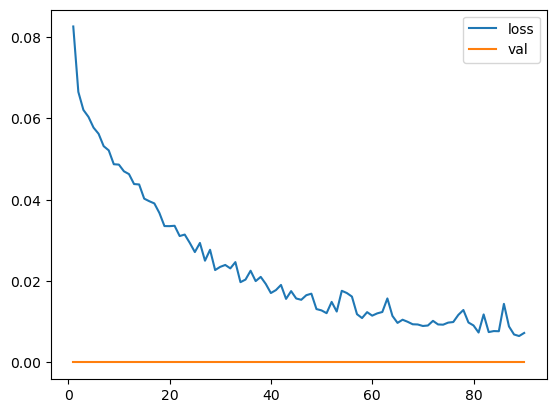

In [192]:
path_model='./constant_resnet_sum_myloss_lr0p00005/models/'
#path_model='./constant_resnet_sum_myloss_lr0p0005_nograd/models/'
#path_model='./resized_vgg_sum_myloss_pret_lr0p00001/models/'
path_model='./resized_vgg_sum_myloss_pret_lr0p00001_class_weight/models/'

name_out='./curves/'
plot_val_loss(path_model)